In [25]:
# Import
import numpy as np
import pandas as pd
import scanpy as sc
import anndata
import matplotlib.pyplot as plt
import os
import milopy as milo
import tqdm as notebook_tqdm
from anndata import AnnData
import logging
import random
import re
import scipy.sparse
from scipy.sparse import csr_matrix

In [24]:
!git clone 'https://github.com/emdann/milopy.git'

fatal: destination path 'milopy' already exists and is not an empty directory.


In [29]:
cd ..

/lila/data/chanjlab/CRC_ZFP36L2.092023/Organoid/scripts/organoid_analysis_pipeline_scripts/milopy


In [30]:
pip install .

Defaulting to user installation because normal site-packages is not writeable
Processing /lila/data/chanjlab/CRC_ZFP36L2.092023/Organoid/scripts/organoid_analysis_pipeline_scripts/milopy
  DEPRECATION: A future pip version will change local packages to be built in-place without first copying to a temporary directory. We recommend you use --use-feature=in-tree-build to test your packages with this new behavior before it becomes the default.
   pip 21.3 will remove support for this functionality. You can find discussion regarding this at https://github.com/pypa/pip/issues/7555.
  Using cached rpy2-3.5.15.tar.gz (219 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
    Preparing wheel metadata ... done
  Created wheel for milopy: filename=milopy-0.1.1-py3-none-any.whl size=11575 sha256=17e858a9d01c13643ab71ab7923f3b7511e702afaefd2393af74f52d6c57e4da
  Stored in directory: /scratch/lsftmp/3865895.tmpdir/pip-ephem-wheel-cache-yodo_884/wheels/eb/d3/

  ERROR: Command errored out with exit status 1:
   command: /opt/common/CentOS_7/anaconda/anaconda3/envs/jupyter-4.9.1/bin/python /opt/common/CentOS_7/anaconda/anaconda3/envs/jupyter-4.9.1/lib/python3.9/site-packages/pip/_vendor/pep517/in_process/_in_process.py build_wheel /scratch/lsftmp/3865895.tmpdir/tmp8uefk06q
       cwd: /scratch/lsftmp/3865895.tmpdir/pip-install-v35l0t3d/rpy2_b296c09971db432694dc1c26836a2f63
  Complete output (207 lines):
  cffi mode is CFFI_MODE.ANY
  Looking for R home with: R RHOME
  R home found: /home/forsythb/anaconda3/envs/milopy/lib/R
  R exec path: /home/forsythb/anaconda3/envs/milopy/lib/R/bin/R
  Looking for R CONFIG with: /home/forsythb/anaconda3/envs/milopy/lib/R/bin/R CMD config --ldflags
  ['-Wl,--export-dynamic -fopenmp -Wl,-O2 -Wl,--sort-common -Wl,--as-needed -Wl,-z,relro -Wl,-z,now -Wl,--disable-new-dtags -Wl,--gc-sections -Wl,--allow-shlib-undefined -Wl,-rpath,/home/forsythb/anaconda3/envs/milopy/lib -Wl,-rpath-link,/home/forsythb/anaconda3/

  no previously-included directories found matching 'dist'
  adding license file 'LICENSE'
  adding license file 'AUTHORS'
  writing manifest file 'rpy2.egg-info/SOURCES.txt'
  copying rpy2/rinterface_lib/R_API.h -> build/lib.linux-x86_64-cpython-39/rpy2/rinterface_lib
  copying rpy2/rinterface_lib/R_API_eventloop.h -> build/lib.linux-x86_64-cpython-39/rpy2/rinterface_lib
  copying rpy2/rinterface_lib/R_API_eventloop.c -> build/lib.linux-x86_64-cpython-39/rpy2/rinterface_lib
  copying rpy2/rinterface_lib/RPY2.h -> build/lib.linux-x86_64-cpython-39/rpy2/rinterface_lib
  copying rpy2/rinterface_lib/_bufferprotocol.c -> build/lib.linux-x86_64-cpython-39/rpy2/rinterface_lib
  file _rinterface_cffi_abi.py (for module _rinterface_cffi_abi) not found
  generating cffi module 'build/lib.linux-x86_64-cpython-39/_rinterface_cffi_abi.py'
  running build_ext
  generating cffi module 'build/temp.linux-x86_64-cpython-39/_rinterface_cffi_api.c'
  creating build/temp.linux-x86_64-cpython-39
  building

In [2]:
sc.__version__

'1.9.6'

In [3]:
# Read adata
adata = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/postprocess_adata/adata.combined.postprocess.leiden.h5ad')

In [8]:
adata

AnnData object with n_obs × n_vars = 52800 × 31806
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log10GenesPerUMI', 'original_total_counts', 'log10_original_total_counts', 'mito_frac', 'Patient', 'Tumor_Site', 'Culture_Media', 'ZFP_Expression', 'Replicate', 'Batch', 'Sample', 'phenograph', 'leiden', 'leiden_res_.25', 'leiden_res_.5', 'leiden_res_1', 'leiden_res_0.1'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ribo', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'diffmap_evals', 'hvg', 'leiden', 'log1p', 'neighbors', 'num_components', 'paga', 'phenograph_sizes', 'rank_genes

In [5]:
# Build KNN graph
d = 30
k = 30

sc.pp.neighbors(adata, n_neighbors=k, n_pcs=d)

In [12]:
adata

AnnData object with n_obs × n_vars = 52800 × 31806
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log10GenesPerUMI', 'original_total_counts', 'log10_original_total_counts', 'mito_frac', 'Patient', 'Tumor_Site', 'Culture_Media', 'ZFP_Expression', 'Replicate', 'Batch', 'Sample', 'phenograph', 'leiden', 'leiden_res_.25', 'leiden_res_.5', 'leiden_res_1', 'leiden_res_0.1'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ribo', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'diffmap_evals', 'hvg', 'leiden', 'log1p', 'neighbors', 'num_components', 'paga', 'phenograph_sizes', 'rank_genes

In [17]:
# Make nhoods
def make_nhoods(
        adata: AnnData,
        neighbors_key: str = None,
        prop=0.1,
        seed: int = 42):
    '''
    This function randomly samples vertcies on a graph to define neighbourhoods.
    These are then refined by computing the median profile for the neighbourhood
    in reduced dimensional space and selecting the nearest vertex to this
    position. Thus, multiple neighbourhoods may be collapsed down together to
    prevent over-sampling the graph space.

    - adata: AnnData object. Should contain a knn graph in `adata.obsp`
    - neighbors_key: string indicating the key in `adata.obsp` to use as KNN graph. If not specified, 
    `make_nhoods` looks .obsp[‘connectivities’] for connectivities (default storage places for
    `scanpy.pp.neighbors`). If specified, it looks .obsp[.uns[neighbors_key][‘connectivities_key’]] for
    connectivities.
    - prop: fraction of cells to sample for neighbourhood index search (default: 0.1)
    - seed: random seed for cell sampling (default: 42)
    '''
    # Get reduced dim used for KNN graph
    if neighbors_key is None:
        try:
            use_rep = adata.uns["neighbors"]["params"]["use_rep"]
        except KeyError:
            logging.warning('Using X_pca as default embedding')
            use_rep = "X_pca"
        try:
            knn_graph = adata.obsp["connectivities"].copy()
        except KeyError:
            raise KeyError(
                'No "connectivities" slot in adata.obsp -- please run scanpy.pp.neighbors(adata) first'
            )
    else:
        try:
            use_rep = adata.uns[neighbors_key]["params"]["use_rep"]
        except KeyError:
            logging.warning('Using X_pca as default embedding')
            use_rep = "X_pca"
        knn_graph = adata.obsp[neighbors_key + "_connectivities"].copy()

    # Get reduced dim
    if use_rep == 'X':
        X_dimred = adata.X
        if scipy.sparse.issparse(X_dimred):
            X_dimred = X_dimred.A
    else:
        X_dimred = adata.obsm[use_rep]

    # Sample size
    n_ixs = int(np.round(adata.n_obs * prop))

    # Binarize
    knn_graph[knn_graph != 0] = 1

    #  Sample random vertices
    random.seed(seed)
    random_vertices = random.sample(range(adata.n_obs), k=n_ixs)
    random_vertices.sort()

    ixs_nn = knn_graph[random_vertices, :]

    # Refine sampling
    non_zero_rows = ixs_nn.nonzero()[0]
    non_zero_cols = ixs_nn.nonzero()[1]

    nh_reduced_dims = np.empty(shape=[0, X_dimred.shape[1]])
    refined_vertices = np.empty(shape=[len(random_vertices), ])

    from sklearn.metrics.pairwise import euclidean_distances
    for i in range(len(random_vertices)):
        nh_pos = np.median(
            X_dimred[non_zero_cols[non_zero_rows == i], :], 0).reshape(-1, 1)
        nn_ixs = non_zero_cols[non_zero_rows == i]
        # Find closest real point (amongst nearest neighbors)
        dists = euclidean_distances(
            X_dimred[non_zero_cols[non_zero_rows == i], :], nh_pos.T)
        # Update vertex index
        refined_vertices[i] = nn_ixs[dists.argmin()]

    refined_vertices = np.unique(refined_vertices.astype("int"))
    refined_vertices.sort()

    nhoods = knn_graph[:, refined_vertices]
    adata.obsm['nhoods'] = nhoods

    # Add ixs to adata
    adata.obs["nhood_ixs_random"] = adata.obs_names.isin(
        adata.obs_names[random_vertices])
    adata.obs["nhood_ixs_refined"] = adata.obs_names.isin(
        adata.obs_names[refined_vertices])
    adata.obs["nhood_ixs_refined"] = adata.obs["nhood_ixs_refined"].astype(
        "int")
    adata.obs["nhood_ixs_random"] = adata.obs["nhood_ixs_random"].astype("int")
    # Store info on neighbor_key used
    adata.uns["nhood_neighbors_key"] = neighbors_key
    # Store distance to K-th nearest neighbor (used for spatial FDR correction)
    if neighbors_key is None:
        k = adata.uns["neighbors"]["params"]["n_neighbors"]
        knn_dists = adata.obsp["distances"]
    else:
        k = adata.uns[neighbors_key]["params"]["n_neighbors"]
        knn_dists = adata.obsp[neighbors_key + "_distances"]
    nhood_ixs = adata.obs["nhood_ixs_refined"] == 1
    dist_mat = knn_dists[nhood_ixs, :]
    k_distances = dist_mat.max(1).toarray().ravel()
    adata.obs["nhood_kth_distance"] = 0
    adata.obs.loc[adata.obs["nhood_ixs_refined"]
                  == 1, "nhood_kth_distance"] = k_distances


In [18]:
# Construct neighborhoods
make_nhoods(adata, prop=0.1)

/scratch/lsftmp/3870605.tmpdir/ipykernel_259547/4163677609.py:109: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[6.46169567 8.55352592 5.9185195  ... 6.48300076 9.95076466 7.09391069]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  adata.obs.loc[adata.obs["nhood_ixs_refined"]


In [19]:
adata.obsm["nhoods"]

<52800x3574 sparse matrix of type '<class 'numpy.float32'>'
	with 220348 stored elements in Compressed Sparse Row format>

In [20]:
adata[adata.obs['nhood_ixs_refined'] != 0].obs[['nhood_ixs_refined', 'nhood_kth_distance']]

,nhood_ixs_refined,nhood_kth_distance
KG146Li_HISC_shZFP36L2_3_TGAGGTTCAACGTAAA-1,1,6.461696
146P_HISC_shCTRL_AGGCCACCAAGATTGA-1,1,8.553526
146P_dedifferentiation_shZFP36L2_3_AGCGCCATCCTACTGC-1,1,5.918519
146P_dedifferentiation_shZFP36L2_4_TGCATCCGTCTACACA-1,1,7.365753
KG146Li_BASE_shZFP36L2_4_GAACTGTTCGGTTAGT-1,1,5.868186
...,...,...
146P_BASE_shZFP36L2_4_ATCTCTAGTACTAACC-1,1,8.164231
146P_dedifferentiation_shZFP36L2_3_GTCTCACAGTTCCAGT-1,1,8.905218
146P_dedifferentiation_shZFP36L2_3_GGCTTGGGTGGCCCAT-1,1,6.483001
146P_HISC_shZFP36L2_4_AGATCGTAGCAGTAAT-1,1,9.950765


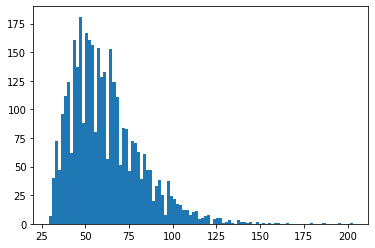

In [21]:
nhood_size = np.array(adata.obsm["nhoods"].sum(0)).ravel()
plt.hist(nhood_size, bins=100);

In [26]:
def count_nhoods(
    adata: AnnData,
    sample_col: str,
):
    '''
    - adata
    - sample_col: string, column in adata.obs that contains sample information 
    (what should be in the columns of the nhoodCount matrix)

    Returns: None
    Updated adata.uns slot to contain adata.uns["nhood_adata"], where:
    - adata.uns["nhood_adata"].obs_names are neighbourhoods
    - adata.uns["nhood_adata"].var_names are samples
    - adata.uns["nhood_adata"].X is the matrix counting the number of cells from each
    sample in each neighbourhood
    '''
    try:
        nhoods = adata.obsm["nhoods"]
    except KeyError:
        raise KeyError(
            'Cannot find "nhoods" slot in adata.obsm -- please run milopy.make_nhoods(adata)'
        )
    #  Make nhood abundance matrix
    sample_dummies = pd.get_dummies(adata.obs[sample_col])
    all_samples = sample_dummies.columns
    sample_dummies = scipy.sparse.csr_matrix(sample_dummies.values)
    nhood_count_mat = adata.obsm["nhoods"].T.dot(sample_dummies)
    nhood_var = pd.DataFrame(index=all_samples)
    nhood_adata = anndata.AnnData(X=nhood_count_mat, var=nhood_var)
    nhood_adata.uns["sample_col"] = sample_col
    # Save nhood index info
    nhood_adata.obs["index_cell"] = adata.obs_names[adata.obs["nhood_ixs_refined"] == 1]
    nhood_adata.obs["kth_distance"] = adata.obs.loc[adata.obs["nhood_ixs_refined"]
                                                    == 1, "nhood_kth_distance"].values
    adata.uns["nhood_adata"] = nhood_adata

In [27]:
# Count neighborhoods
count_nhoods(adata, sample_col="Sample")

In [28]:
adata.uns["nhood_adata"]

AnnData object with n_obs × n_vars = 3574 × 18
    obs: 'index_cell', 'kth_distance'
    uns: 'sample_col'

In [29]:
adata.obs.ZFP_Expression

KG146Li_BASE_shCtrl_TGCGGGTTCTCACCCA-1                      CTRL
KG146Li_HISC_shCtrl_ACTATCTGTAACGGTG-1                      CTRL
146P_HISC_shZFP36L2_3_TTGTGTTTCCCAAGTA-1                  ZFP_KD
146Li_dedifferentiation_shCtrl_ATCGATGCACGGAAGT-1           CTRL
146P_HISC_shCTRL_GTCGCGACAAGGCTTT-1                         CTRL
                                                           ...  
146P_dedifferentiation_shCtrl_CTCCGATTCATTCATC-1            CTRL
KG146Li_BASE_shZFP36L2_4_CTGCTCAAGTAGCAAT-1               ZFP_KD
KG146Li_HISC_shZFP36L2_4_ATCCCTGCACGCTTAA-1               ZFP_KD
146Li_dedifferentiation_shCtrl_TACTTGTGTCTTACAG-1           CTRL
146Li_dedifferentiation_shZFP36L2_4_AACAACCAGGGAGAAT-1    ZFP_KD
Name: ZFP_Expression, Length: 52800, dtype: category
Categories (2, object): ['CTRL', 'ZFP_KD']

In [30]:
adata.obs["ZFP_Expression_continuous"] = adata.obs["ZFP_Expression"].cat.codes

In [18]:
cd milopy

[Errno 2] No such file or directory: 'milopy'
/lila/data/chanjlab/CRC_ZFP36L2.092023/Organoid/scripts/organoid_analysis_pipeline_scripts/milopy


/home/forsythb/anaconda3/envs/milopy/lib/python3.10/site-packages/IPython/core/magics/osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})


In [19]:
pip install .

Processing /lila/data/chanjlab/CRC_ZFP36L2.092023/Organoid/scripts/organoid_analysis_pipeline_scripts/milopy
  Preparing metadata (setup.py) ... error
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [8 lines of output]
      running egg_info
      creating /scratch/lsftmp/3865895.tmpdir/pip-pip-egg-info-63rp_u_q/milopy.egg-info
      writing /scratch/lsftmp/3865895.tmpdir/pip-pip-egg-info-63rp_u_q/milopy.egg-info/PKG-INFO
      writing dependency_links to /scratch/lsftmp/3865895.tmpdir/pip-pip-egg-info-63rp_u_q/milopy.egg-info/dependency_links.txt
      writing requirements to /scratch/lsftmp/3865895.tmpdir/pip-pip-egg-info-63rp_u_q/milopy.egg-info/requires.txt
      writing top-level names to /scratch/lsftmp/3865895.tmpdir/pip-pip-egg-info-63rp_u_q/milopy.egg-info/top_level.txt
      writing manifest file '/scratch/lsftmp/3865895.tmpdir/pip-pip-egg-info-63rp_u_q/milopy.egg-info/SOURCES.txt'
      error: package dir

In [2]:
import milopy as milo
import milopy.plot as milopl

ModuleNotFoundError: No module named 'milopy.plot'

In [10]:
os.environ['R_home'] = '/anaconda3/envs/milopy/R'
import anndata2ri
import rpy2.rinterface_lib.callbacks
import logging

ValueError: openrlib.R_HOME cannot be None.

In [ ]:
pip install anndata2ri

In [3]:
plt.rcParams['figure.figsize']=(8,8) #rescale figures
sc.settings.verbosity = 3

ValueError: r_home is None. Try python -m rpy2.situation